In [25]:
import pandas as pd 
import numpy as np 
import palantir 
import scanpy as sc
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [26]:
im_and_spm = sc.read_h5ad('/data/passala/Collaborator_Data/Maize_arabi_Jack_Collab/Running_palantir/IM.h5ad')

In [27]:
im_and_spm

AnnData object with n_obs × n_vars = 3402 × 28492
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'DataSet', 'integrated_snn_res.0.85', 'seurat_clusters', 'integrated_snn_res.0.65', 'mygraph_res.0.8', 'subcluster6', 'integrated_snn_res.0.5'
    var: 'features'
    obsm: 'X_umap'

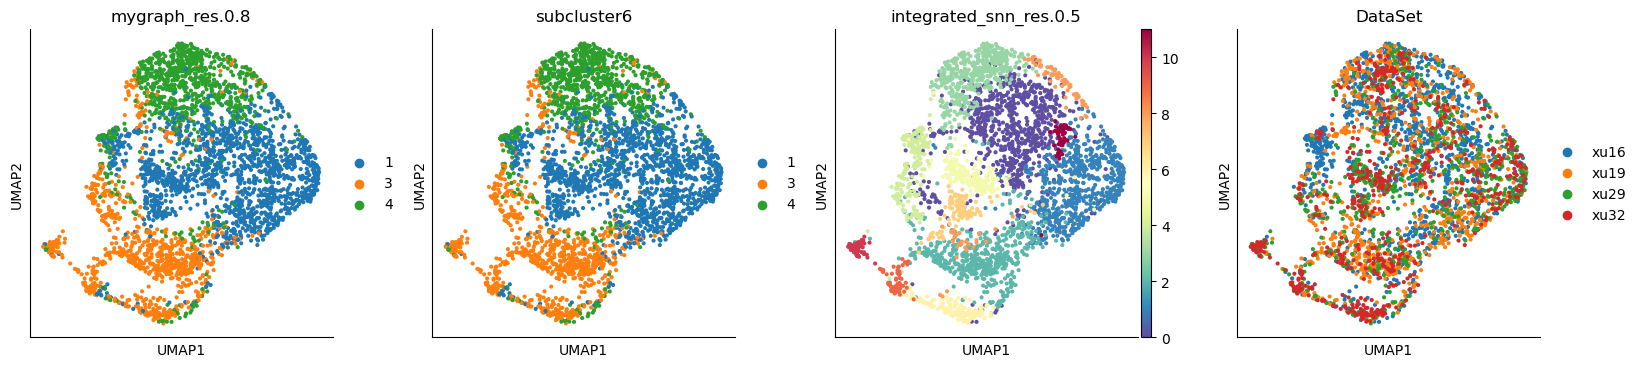

In [28]:
sc.plotting.umap(im_and_spm, color = ['mygraph_res.0.8', 'subcluster6', 'integrated_snn_res.0.5','DataSet'], )

In [29]:
im_and_spm.var.loc[im_and_spm.var['features'] == 'GRMZM2G372364']

,features
GRMZM2G372364,GRMZM2G372364


IM ONLY
Starting Cells 
Subcluster 6, Cluster 3 = IM Stem Cells, GRMZM2G372364

Terminal Cells 
Subcluster 6, cluster 1 = Cortex ,GRMZM2G345700 
Subluster 6, Cluster 4 = Pith, GRMZM2G430849


On IM only run Palantir with Just Cle7 as starting cell, and then also run with Cortex and Pith as Terminally differentiated cells 


IM and SPM 
Starting Cells 
Subcluster 6, Cluster 3 = IM Stem Cells, GRMZM2G372364

Terminal Cells 
Subcluster 6, Cluster 6_0 = Meristem Base, GRMZM2G014729
Subcluster 6, Cluster 6_1 = Determinate Lateral Organ, GRMZM2G529859
Subcluster 6, Cluster 12 = Adaxiam meristem periphery, GRMZM2G072274
Subcluster 6, Cluster 14 = Vasculature, GRMZM2G132794 
Subcluster 6, cluster 1 = Cortex ,GRMZM2G345700 
Subluster 6, Cluster 4 = Pith, GRMZM2G430849


On IM SPM run Palantir with Just Cle7 as starting cell, and then also run with all 6 terminally differentiated 


In [30]:
marker_genes_dict = {
    "Stem Cell": ["GRMZM2G372364", "GRMZM2G047448"],
    "Pith": ["GRMZM2G047448", "GRMZM2G372364"],
    "Cortex":["GRMZM2G047448", "GRMZM2G372364"],

}

In [31]:
im_and_spm.raw = im_and_spm

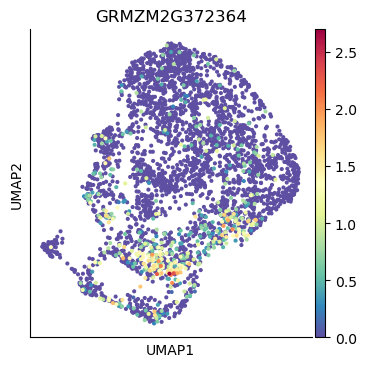

In [32]:
sc.pl.umap(im_and_spm, color ='GRMZM2G372364')

In [33]:
sc.pp.highly_variable_genes(im_and_spm, n_top_genes=1000)
sc.pp.pca(im_and_spm)

In [34]:
dm_res = palantir.utils.run_diffusion_maps(im_and_spm, n_components=5)
ms_data = palantir.utils.determine_multiscale_space(im_and_spm)


In [35]:
# sc.pp.neighbors(im_and_spm)
# sc.tl.umap(im_and_spm)

In [36]:
# sc.pl.embedding(
#     im_and_spm,
#     basis="umap",
#     frameon=False,
# )

In [37]:
#imputed_X = palantir.utils.run_magic_imputation(im_and_spm)


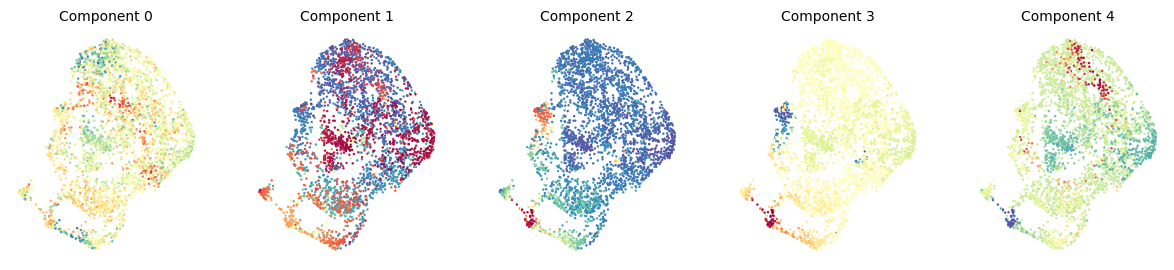

In [38]:
palantir.plot.plot_diffusion_components(im_and_spm)
plt.show()

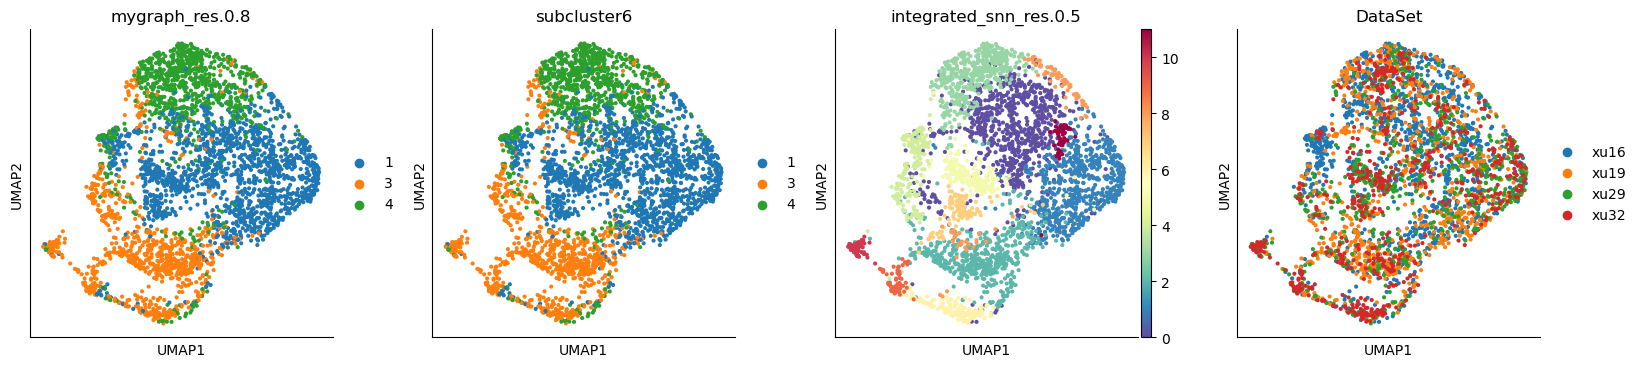

In [39]:
sc.plotting.umap(im_and_spm, color = ['mygraph_res.0.8', 'subcluster6', 'integrated_snn_res.0.5','DataSet'], )

IM and SPM 
Starting Cells 
Subcluster 6, Cluster 3 = IM Stem Cells, GRMZM2G372364

Terminal Cells 
Subcluster 6, Cluster 6_0 = Meristem Base, GRMZM2G014729
Subcluster 6, Cluster 6_1 = Determinate Lateral Organ, GRMZM2G529859
Subcluster 6, Cluster 12 = Adaxiam meristem periphery, GRMZM2G072274
Subcluster 6, Cluster 14 = Vasculature, GRMZM2G132794 
Subcluster 6, cluster 1 = Cortex ,GRMZM2G345700 
Subluster 6, Cluster 4 = Pith, GRMZM2G430849

In [40]:
def identify_strongest_cell_in_cluster_with_marker(imputed_data, cluster, marker_gene):
    imputed_data_trimmed = imputed_data[imputed_data.obs["subcluster6"] == cluster, imputed_data.var["features"] == marker_gene]
    imputed_data_dense = pd.DataFrame(data = imputed_data_trimmed.X.todense(), index = imputed_data_trimmed.obs.index, columns = imputed_data_trimmed.var.index)
    return imputed_data_dense.sort_values(by = marker_gene, ascending = False).head(3)

In [41]:
identify_strongest_cell_in_cluster_with_marker(im_and_spm, "3", "GRMZM2G372364")

,GRMZM2G372364
GCACGGTAGAGCCATG-1_2,2.695609
AACCACAGTGGGATTG-1_2,2.310816
CCGATGGAGGTGATAT-1_1,2.256228


In [42]:
start_cell = "AACCACAGTGGGATTG-1_2"


In [43]:
terminal_states = pd.Series(
    ["Cortex","Pith"],
    index=[ "GTAGAGGAGGAAAGTG-1_4", "CAATTTCGTCATATGC-1_1"],
)

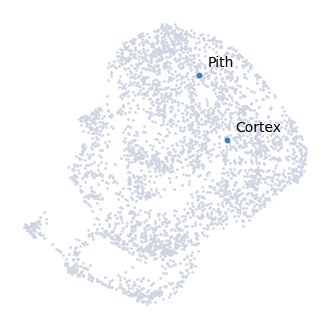

In [44]:
palantir.plot.highlight_cells_on_umap(im_and_spm, terminal_states)
plt.show()

In [45]:
pr_res = palantir.core.run_palantir(
    im_and_spm, start_cell, num_waypoints=500,
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00411375363667806 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.1586605429649353 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


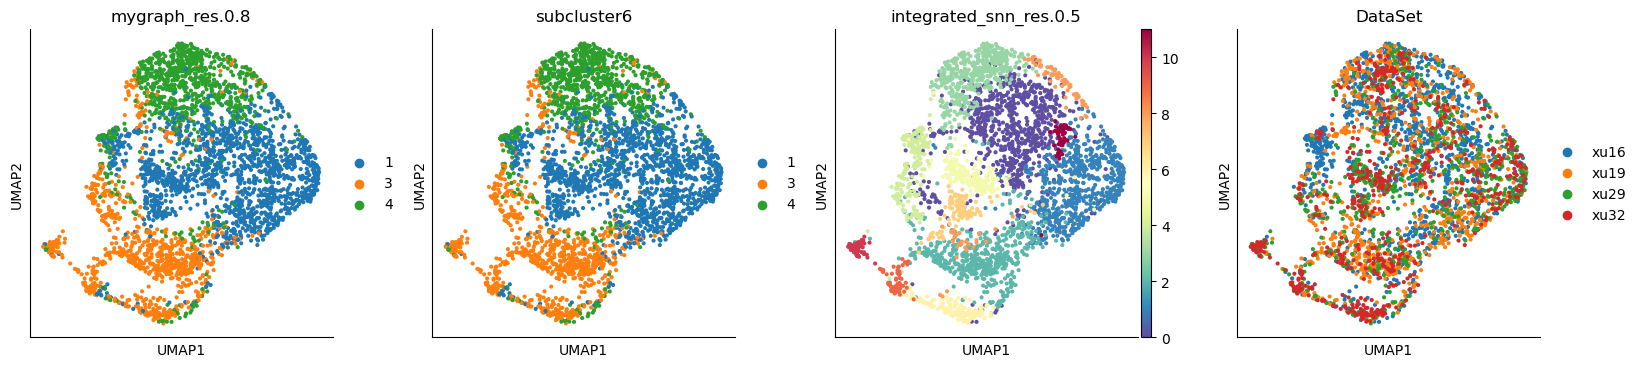

In [49]:
sc.plotting.umap(im_and_spm, color = ['mygraph_res.0.8', 'subcluster6', 'integrated_snn_res.0.5','DataSet'], )

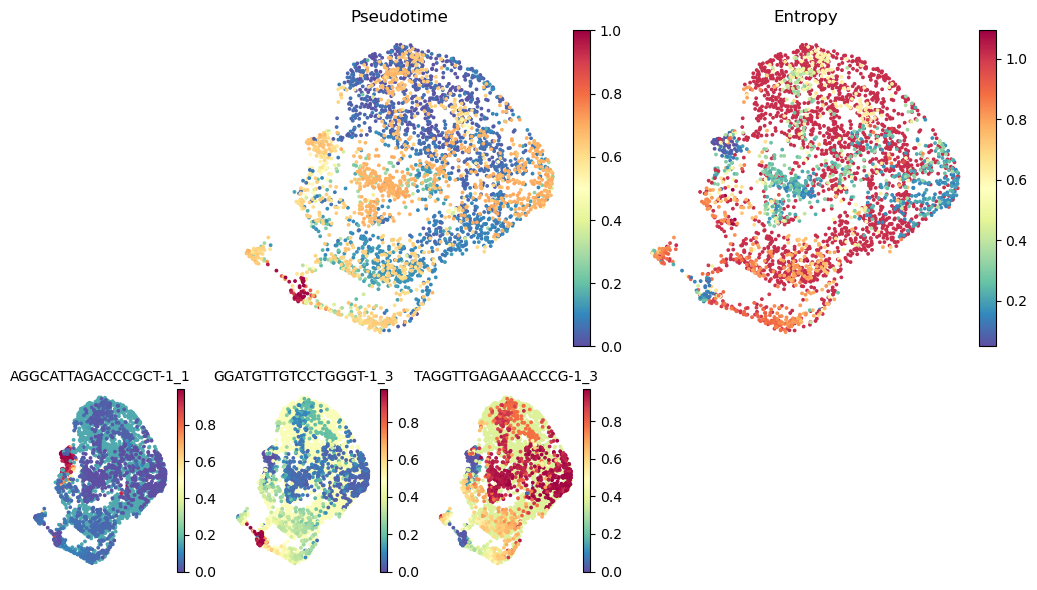

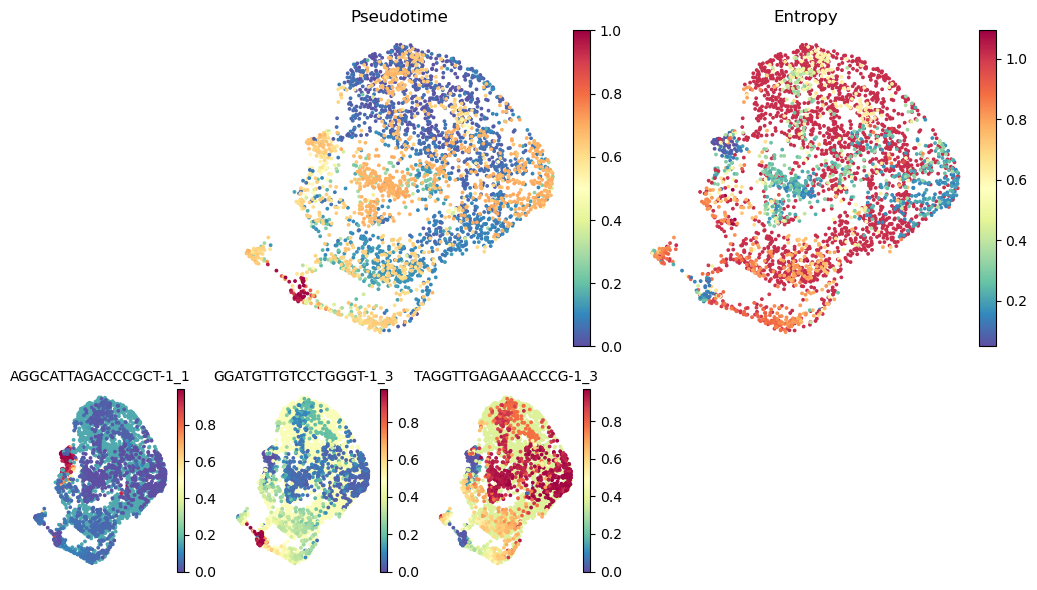

In [46]:
palantir.plot.plot_palantir_results(im_and_spm, s=3)


In [59]:
pr_res = palantir.core.run_palantir(
    im_and_spm, start_cell, num_waypoints=500, terminal_states=terminal_states
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.0025986313819885256 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/home/passala/miniconda3/envs/palantir/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Time for shortest paths: 0.07193527619043986 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


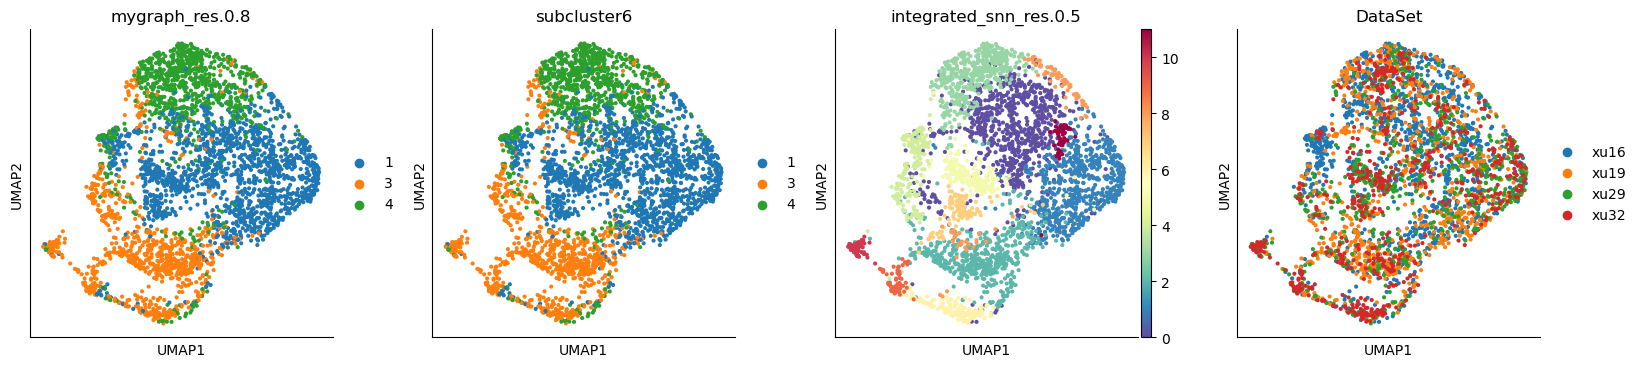

In [60]:
sc.plotting.umap(im_and_spm, color = ['mygraph_res.0.8', 'subcluster6', 'integrated_snn_res.0.5','DataSet'], )

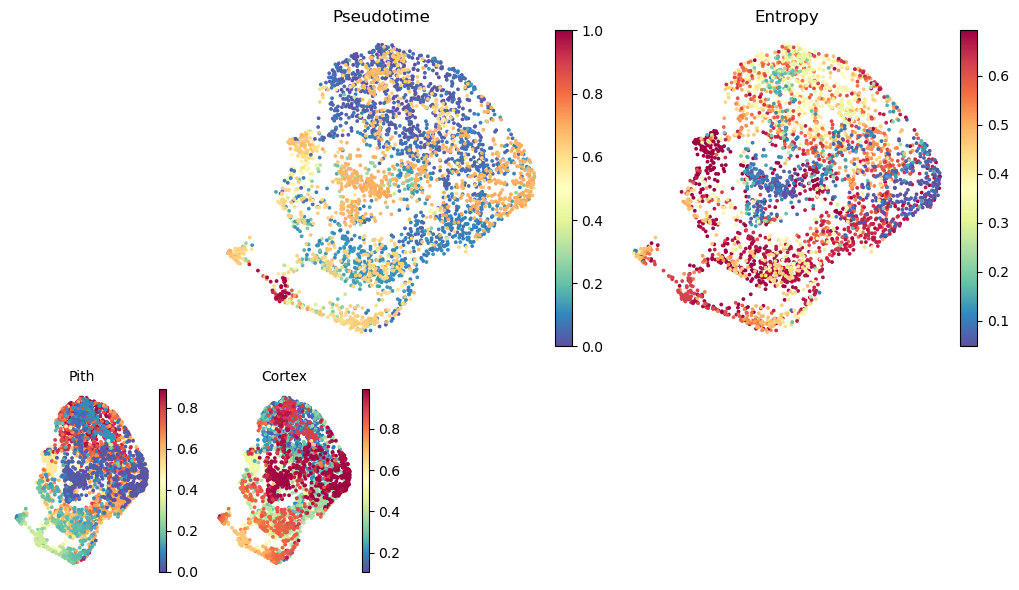

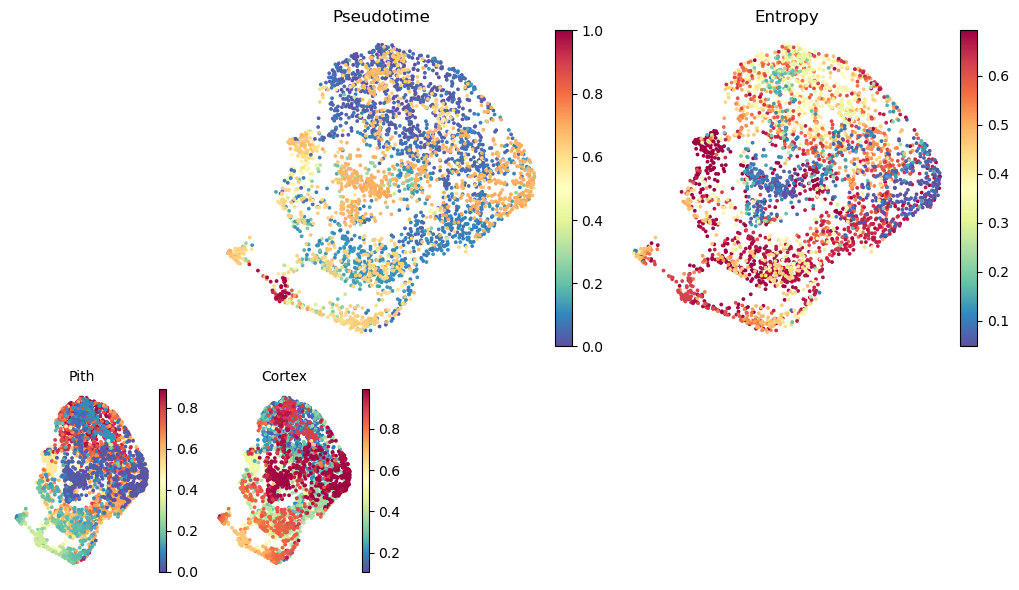

In [61]:
palantir.plot.plot_palantir_results(im_and_spm, s=3)


[2025-02-17 15:49:20,328] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (2,599) and rank = 1.0.
[2025-02-17 15:49:20,329] [INFO    ] Using covariance function Matern52(ls=0.8603307130790651).
[2025-02-17 15:49:20,330] [INFO    ] Computing 50 landmarks with k-means clustering.


[2025-02-17 15:49:20,616] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: Cortex'}, xlabel='UMAP1', ylabel='UMAP2'>

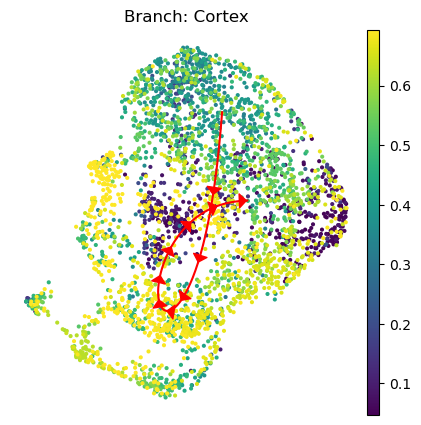

In [64]:
palantir.plot.plot_trajectory(
    im_and_spm,
    "Cortex",
    cell_color="palantir_entropy",
    n_arrows=10,
    color="red",
    scanpy_kwargs=dict(cmap="viridis"),
    arrowprops=dict(arrowstyle="-|>,head_length=.5,head_width=.5"),)

In [65]:
masks = palantir.presults.select_branch_cells(im_and_spm, q=.01, eps=.01)

In [57]:
gene_trends = palantir.presults.compute_gene_trends(im_and_spm)


Pith
[2025-02-17 15:32:56,578] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (66) and rank = 1.0.
[2025-02-17 15:32:56,579] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-02-17 15:32:56,889] [INFO    ] Sigma interpreted as element-wise standard deviation.
Cortex
[2025-02-17 15:32:58,036] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,599) and rank = 1.0.
[2025-02-17 15:32:58,037] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-02-17 15:32:58,411] [INFO    ] Sigma interpreted as element-wise standard deviation.


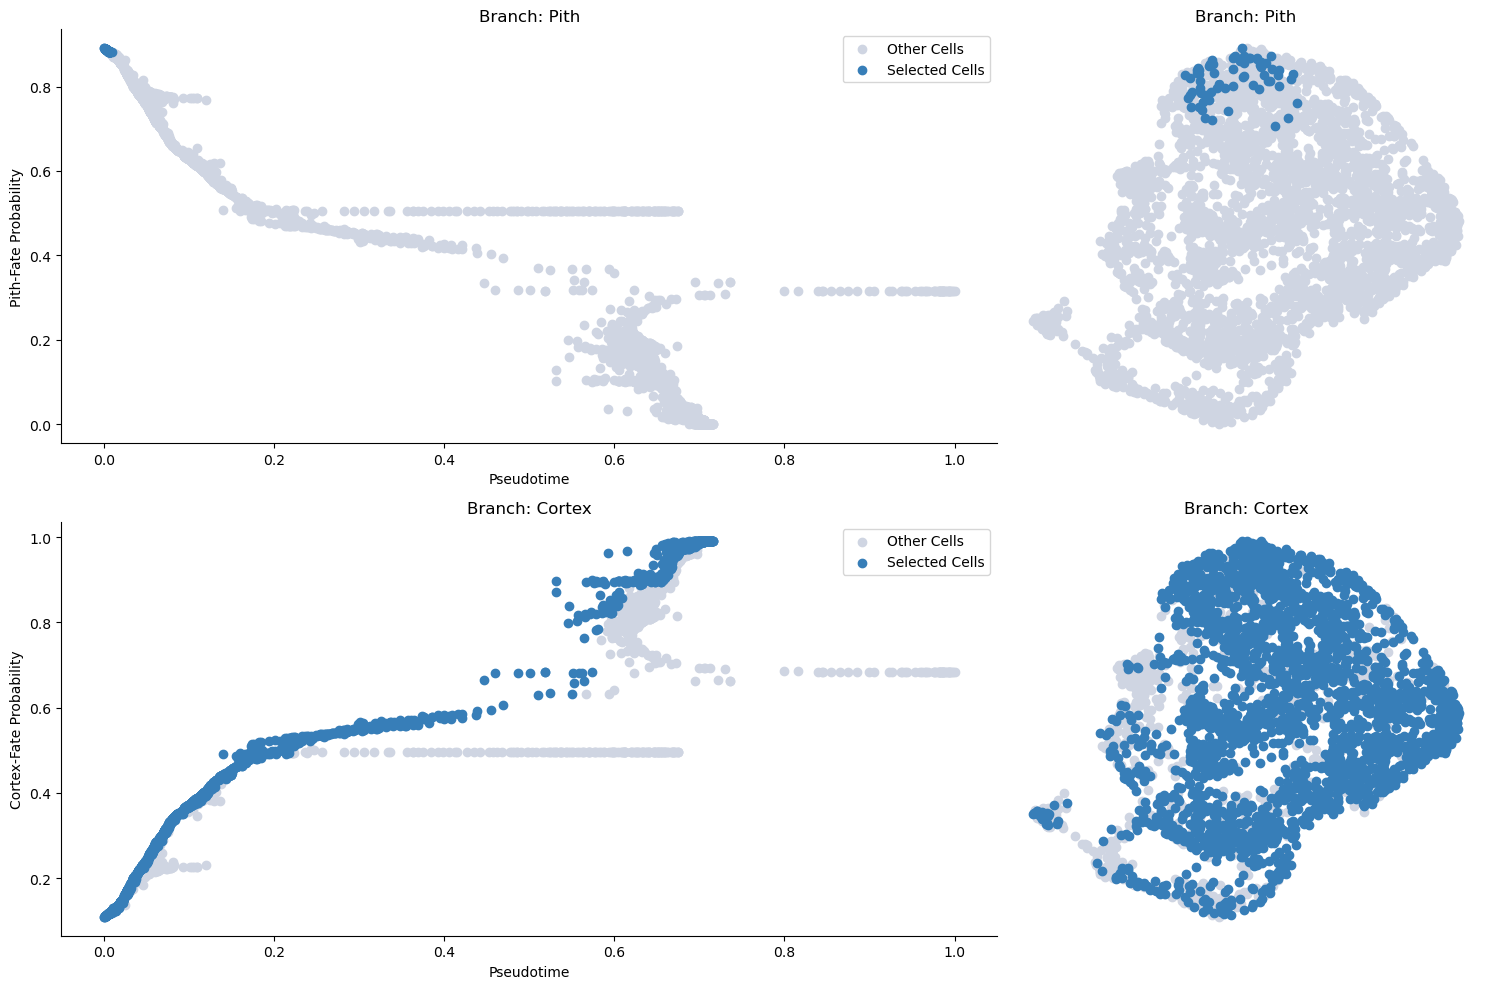

In [66]:
palantir.plot.plot_branch_selection(im_and_spm)
plt.show()

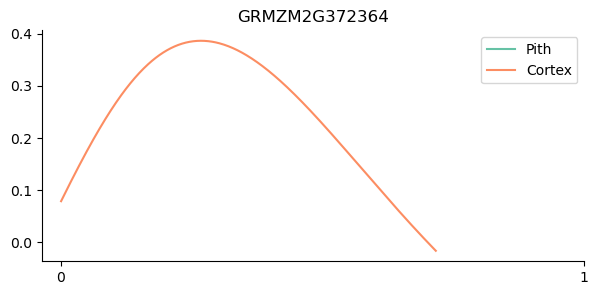

In [54]:
genes = ["GRMZM2G372364"]
palantir.plot.plot_gene_trends(im_and_spm, genes)
plt.show()